# 📊 Unemployment Analysis with Python
### Data Science Project 2 
**Author:** Sanjai KV | **GitHub:** sanjaikv2255

---
**Objective:** Analyze unemployment rate data across Indian states, investigate the impact of COVID-19, identify regional patterns, and compare rural vs urban unemployment trends.

**Datasets Used:**
- `Unemployment_Rate_upto_11_2020.csv` — State-level monthly data (Jan–Nov 2020)
- `Unemployment_in_India.csv` — Rural vs Urban breakdown (May 2019–Jun 2020)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.color': '#e0e0e0', 'grid.alpha': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False
})

COVID_COLOR  = '#e74c3c'
PRE_COLOR    = '#2ecc71'
ACCENT_COLOR = '#3498db'
REGION_COLORS = {'North':'#4C72B0','South':'#DD8452','East':'#55A868','West':'#C44E52','Northeast':'#8172B2'}
print('✅ Libraries loaded')

✅ Libraries loaded


## 2. Load & Clean Data

In [2]:
df1 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')
df2 = pd.read_csv('Unemployment in India.csv')

# Clean column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Rename for convenience
for df in [df1, df2]:
    df.rename(columns={
        'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
        'Estimated Employed': 'Employed',
        'Estimated Labour Participation Rate (%)': 'Labour_Participation'
    }, inplace=True)
    df['Region'] = df['Region'].str.strip()

df1['Date'] = pd.to_datetime(df1['Date'].str.strip(), format='%d-%m-%Y')
df2['Date'] = pd.to_datetime(df2['Date'].str.strip(), format='%d-%m-%Y')
df2.dropna(subset=['Region','Unemployment_Rate'], inplace=True)

df1['Period'] = df1['Date'].apply(lambda d: 'During COVID' if d >= pd.Timestamp('2020-03-01') else 'Pre-COVID')

print(f'Dataset 1: {df1.shape[0]} rows | {df1["Region"].nunique()} states')
print(f'Dataset 2: {df2.shape[0]} rows | {df2["Region"].nunique()} states')
df1.head()

Dataset 1: 267 rows | 27 states
Dataset 2: 740 rows | 28 states


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation,Region.1,longitude,latitude,Period
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,Pre-COVID
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,Pre-COVID
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,During COVID
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,During COVID
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,During COVID


In [3]:
df1.describe().round(2)

,Date,Unemployment_Rate,Employed,Labour_Participation,longitude,latitude
count,267,267.00,267.00,267.00,267.00,267.00
mean,2020-06-16 09:15:30.337078,12.24,13962105.72,41.68,22.83,80.53
min,2020-01-31 00:00:00,0.50,117542.00,16.77,10.85,71.19
25%,2020-03-31 00:00:00,4.84,2838930.50,37.26,18.11,76.09
50%,2020-06-30 00:00:00,9.65,9732417.00,40.39,23.61,79.02
75%,2020-08-31 00:00:00,16.76,21878686.00,44.06,27.28,85.28
max,2020-10-31 00:00:00,75.85,59433759.00,69.69,33.78,92.94
std,NaN,10.80,13366318.36,7.85,6.27,5.83


## 3. National Unemployment Trend

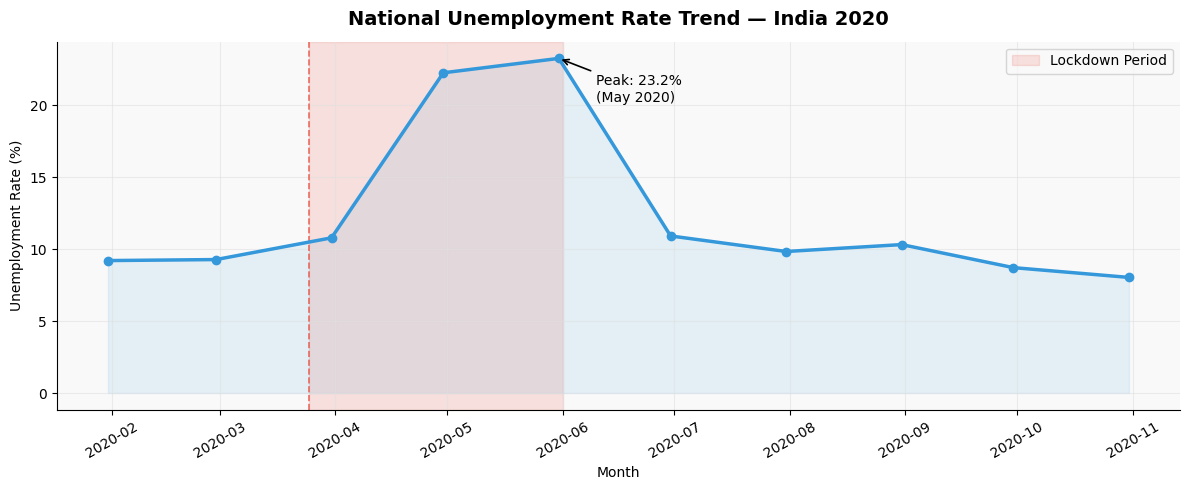


🔍 Key Insight: Unemployment surged from ~9% to 23.2% during COVID lockdown (May 2020)


In [4]:
monthly = df1.groupby('Date')['Unemployment_Rate'].mean().round(2)
peak_date = monthly.idxmax()
peak_val  = monthly.max()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly.index, monthly.values, color=ACCENT_COLOR, linewidth=2.5, marker='o', markersize=6, zorder=3)
ax.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-06-01'), alpha=0.15, color=COVID_COLOR, label='Lockdown Period')
ax.axvline(pd.Timestamp('2020-03-25'), color=COVID_COLOR, linestyle='--', linewidth=1.2, alpha=0.8)
ax.annotate(f'Peak: {peak_val:.1f}%\n({peak_date.strftime("%b %Y")})',
            xy=(peak_date, peak_val), xytext=(peak_date + pd.Timedelta(days=10), peak_val-3),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2), fontsize=10)
ax.fill_between(monthly.index, monthly.values, alpha=0.1, color=ACCENT_COLOR)
ax.set_title('National Unemployment Rate Trend — India 2020', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month'); ax.set_ylabel('Unemployment Rate (%)')
ax.legend(fontsize=10)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plots/01_national_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n🔍 Key Insight: Unemployment surged from ~9% to {peak_val:.1f}% during COVID lockdown (May 2020)')

## 4. COVID-19 Impact Analysis

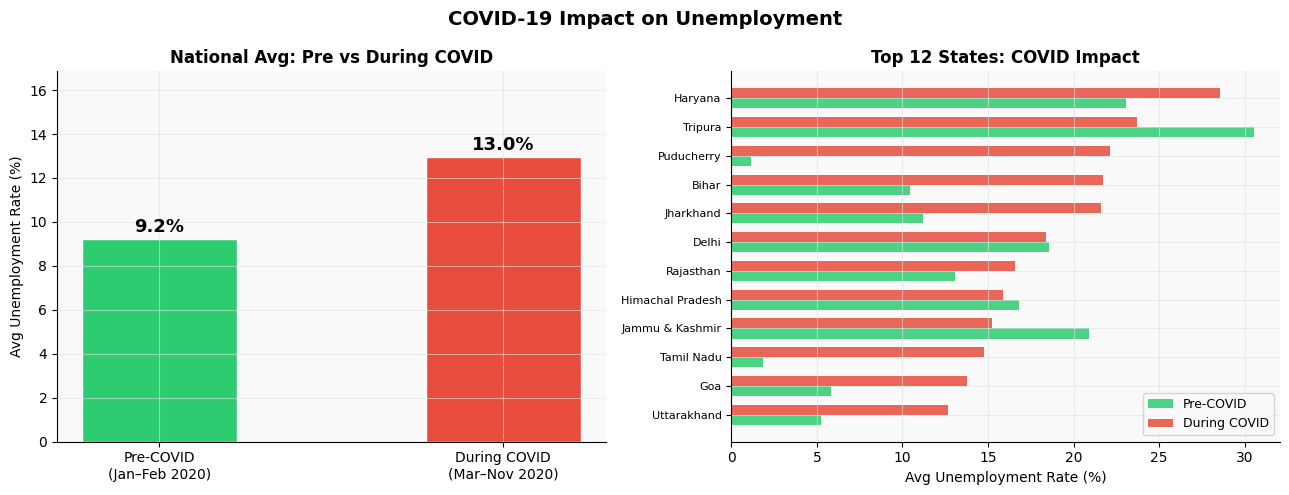


🔍 COVID caused a +3.73% point spike in unemployment nationwide


In [5]:
pre  = df1[df1['Period']=='Pre-COVID']['Unemployment_Rate'].mean()
post = df1[df1['Period']=='During COVID']['Unemployment_Rate'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# National bar
ax = axes[0]
bars = ax.bar(['Pre-COVID\n(Jan–Feb 2020)', 'During COVID\n(Mar–Nov 2020)'],
              [pre, post], color=[PRE_COLOR, COVID_COLOR], width=0.45, edgecolor='white')
for bar, val in zip(bars, [pre, post]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_title('National Avg: Pre vs During COVID', fontsize=12, fontweight='bold')
ax.set_ylabel('Avg Unemployment Rate (%)')
ax.set_ylim(0, post*1.3)

# State-level comparison
state_comp = df1.groupby(['Region','Period'])['Unemployment_Rate'].mean().unstack()
state_comp = state_comp.sort_values('During COVID', ascending=True).tail(12)
x = np.arange(len(state_comp)); w = 0.35
ax2 = axes[1]
ax2.barh(x-w/2, state_comp['Pre-COVID'], height=w, color=PRE_COLOR, alpha=0.85, label='Pre-COVID')
ax2.barh(x+w/2, state_comp['During COVID'], height=w, color=COVID_COLOR, alpha=0.85, label='During COVID')
ax2.set_yticks(x); ax2.set_yticklabels(state_comp.index, fontsize=8)
ax2.set_xlabel('Avg Unemployment Rate (%)'); ax2.set_title('Top 12 States: COVID Impact', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
fig.suptitle('COVID-19 Impact on Unemployment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n🔍 COVID caused a +{post-pre:.2f}% point spike in unemployment nationwide')

## 5. State-wise Analysis

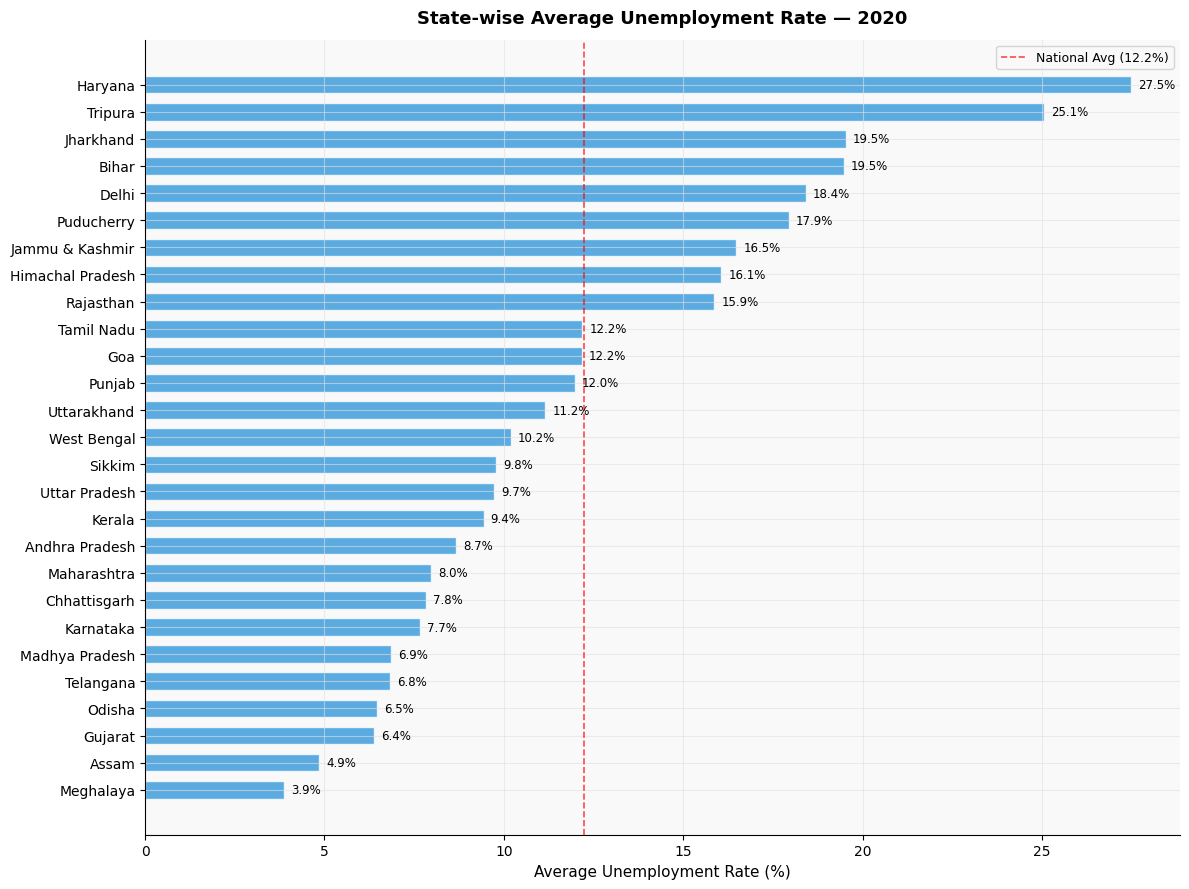


🏆 Highest: Haryana (27.5%)
✅ Lowest:  Meghalaya (3.9%)


In [6]:
state_avg = df1.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(state_avg.index, state_avg.values, color=ACCENT_COLOR, alpha=0.8, edgecolor='white', height=0.65)
for i, val in enumerate(state_avg.values):
    ax.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=8.5)
ax.axvline(state_avg.mean(), color='red', linestyle='--', linewidth=1.2, alpha=0.7, label=f'National Avg ({state_avg.mean():.1f}%)')
ax.set_xlabel('Average Unemployment Rate (%)', fontsize=11)
ax.set_title('State-wise Average Unemployment Rate — 2020', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plots/03_statewise_avg.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n🏆 Highest: {state_avg.idxmax()} ({state_avg.max():.1f}%)')
print(f'✅ Lowest:  {state_avg.idxmin()} ({state_avg.min():.1f}%)')

## 6. State × Month Heatmap

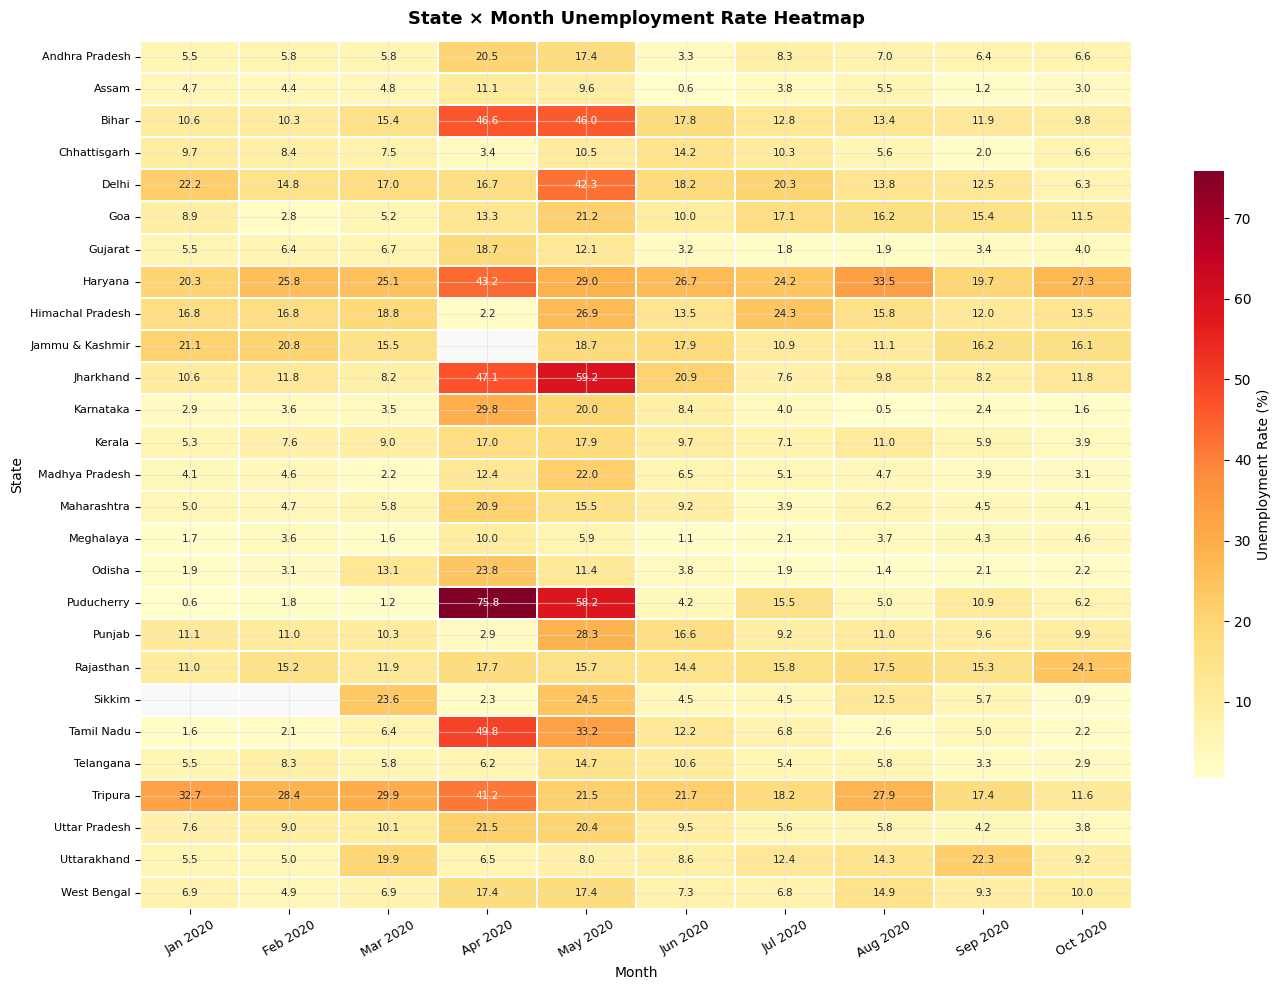

In [7]:
pivot = df1.pivot_table(index='Region', columns='Date', values='Unemployment_Rate', aggfunc='mean')
pivot.columns = [d.strftime('%b %Y') for d in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.3,
            annot_kws={'size':7.5}, cbar_kws={'label':'Unemployment Rate (%)','shrink':0.7})
ax.set_title('State × Month Unemployment Rate Heatmap', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Month'); ax.set_ylabel('State')
plt.xticks(rotation=30, fontsize=9); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('plots/04_heatmap_state_month.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Rural vs Urban Unemployment

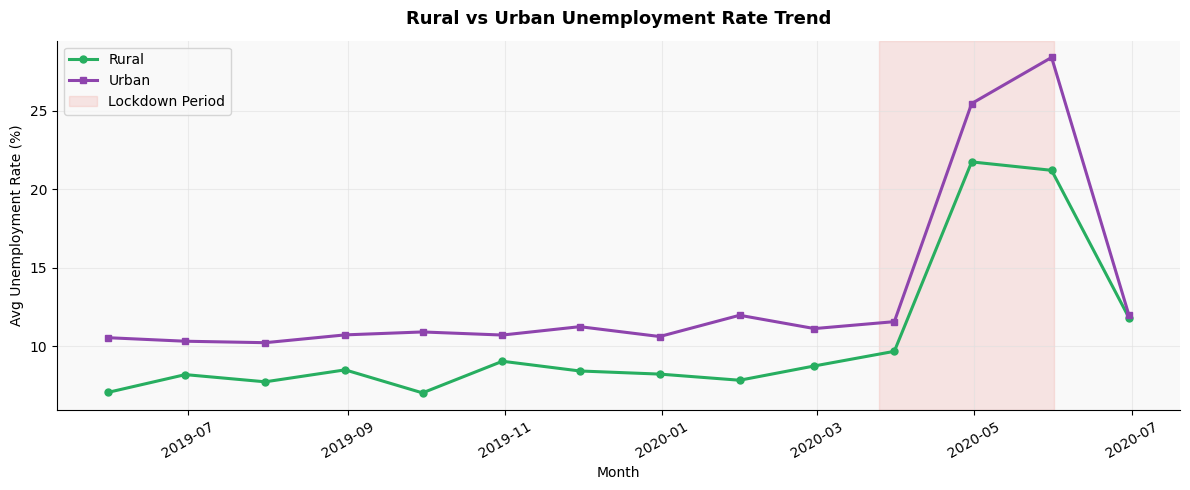

In [8]:
if 'Area' in df2.columns:
    ru = df2.groupby(['Date','Area'])['Unemployment_Rate'].mean().unstack()
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(ru.index, ru.get('Rural',[]), color='#27ae60', linewidth=2.2, marker='o', markersize=5, label='Rural')
    ax.plot(ru.index, ru.get('Urban',[]), color='#8e44ad', linewidth=2.2, marker='s', markersize=5, label='Urban')
    ax.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-06-01'), alpha=0.12, color=COVID_COLOR, label='Lockdown Period')
    ax.set_title('Rural vs Urban Unemployment Rate Trend', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Month'); ax.set_ylabel('Avg Unemployment Rate (%)')
    ax.legend(fontsize=10)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig('plots/05_rural_vs_urban.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Labour Participation vs Unemployment

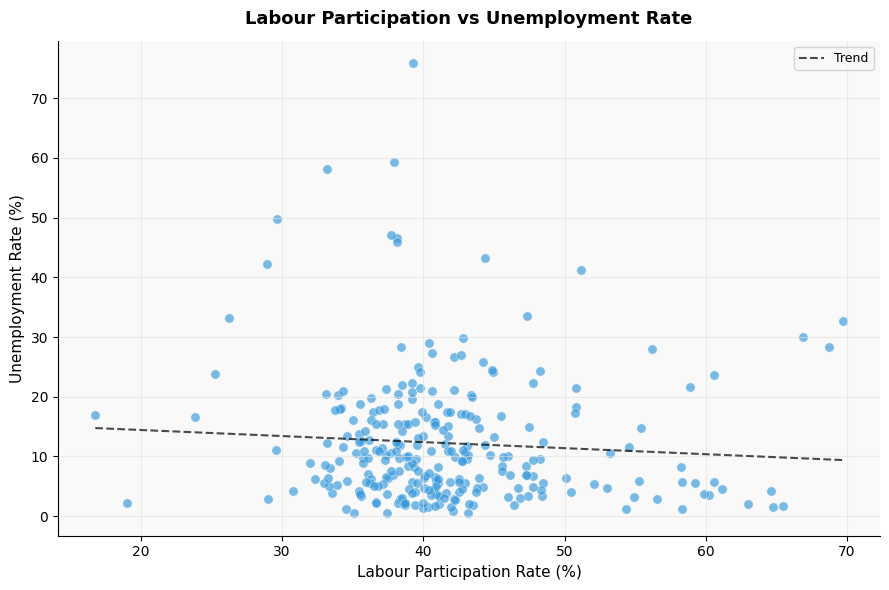

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df1['Labour_Participation'], df1['Unemployment_Rate'], alpha=0.65, s=45,
           color=ACCENT_COLOR, edgecolors='white', linewidths=0.4)
z = np.polyfit(df1['Labour_Participation'].dropna(), df1['Unemployment_Rate'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df1['Labour_Participation'].min(), df1['Labour_Participation'].max(), 100)
ax.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Trend')
ax.set_xlabel('Labour Participation Rate (%)', fontsize=11)
ax.set_ylabel('Unemployment Rate (%)', fontsize=11)
ax.set_title('Labour Participation vs Unemployment Rate', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plots/06_participation_vs_unemployment.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Key Conclusions

In [10]:
print('=' * 58)
print('  KEY FINDINGS SUMMARY')
print('=' * 58)
print(f'''
1. COVID Impact:
   Pre-COVID avg:    {pre:.2f}%
   During COVID avg: {post:.2f}%
   Spike:            +{post-pre:.2f} percentage points

2. Peak unemployment was in May 2020 at {peak_val:.1f}%
   (coinciding with the strictest lockdown period)

3. States hit hardest: Haryana, Tripura, Himachal Pradesh
   States most resilient: Meghalaya, Odisha, Chhattisgarh

4. Urban areas saw sharper unemployment spikes vs Rural,
   likely due to industry/service sector shutdowns

5. By Oct-Nov 2020, unemployment was recovering toward
   pre-COVID levels as restrictions eased
''')

  KEY FINDINGS SUMMARY

1. COVID Impact:
   Pre-COVID avg:    9.23%
   During COVID avg: 12.96%
   Spike:            +3.73 percentage points

2. Peak unemployment was in May 2020 at 23.2%
   (coinciding with the strictest lockdown period)

3. States hit hardest: Haryana, Tripura, Himachal Pradesh
   States most resilient: Meghalaya, Odisha, Chhattisgarh

4. Urban areas saw sharper unemployment spikes vs Rural,
   likely due to industry/service sector shutdowns

5. By Oct-Nov 2020, unemployment was recovering toward
   pre-COVID levels as restrictions eased

